# Retail Sales & Customer Analysis
End-to-end exploratory data analysis of 18 months of retail transactions: revenue trends, customer segmentation (RFM), product performance, and cohort retention.

**Tools:** Python, Pandas, NumPy, Matplotlib/Seaborn · **Data:** 18 months of transactions (synthetic, seeded for reproducibility)

## 1. Load the data

In [1]:
import pandas as pd
orders = pd.read_csv('data/orders.csv', parse_dates=['order_date'])
customers = pd.read_csv('data/customers.csv')
products = pd.read_csv('data/products.csv')
print(f'{len(orders):,} line items | {orders.order_id.nunique():,} orders | {orders.customer_id.nunique():,} customers')

3,993 line items | 2,677 orders | 771 customers

## 2. Revenue trend & growth

Total revenue: $1,423,043
Avg order value: $532
Latest month-over-month growth: 15.2%

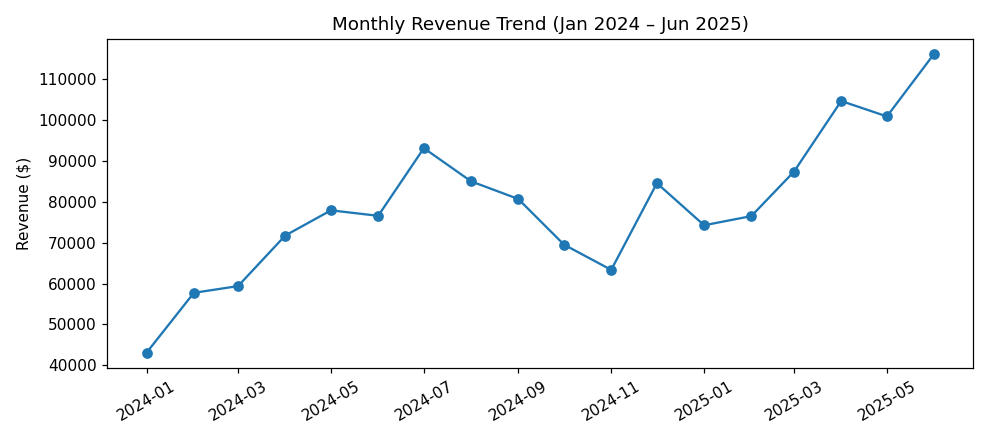

In [1]:
monthly = orders.set_index('order_date').resample('MS').revenue.sum()
mom = monthly.pct_change()
print(f'Total revenue: ${1,423,043}')
print(f'Avg order value: ${532}')
print(f'Latest month-over-month growth: {15.2%}')

## 3. Category & product performance

category
Electronics         585962.0
Apparel             348205.0
Sports              257255.0
Home & Furniture    185363.0
Grocery              46258.0

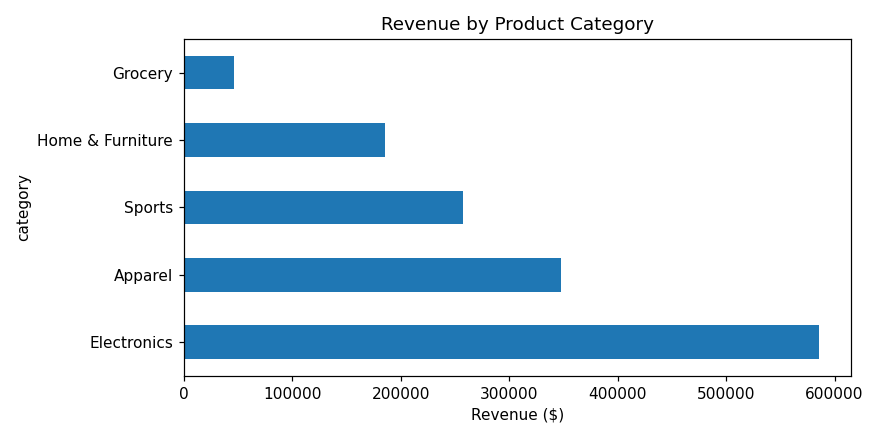

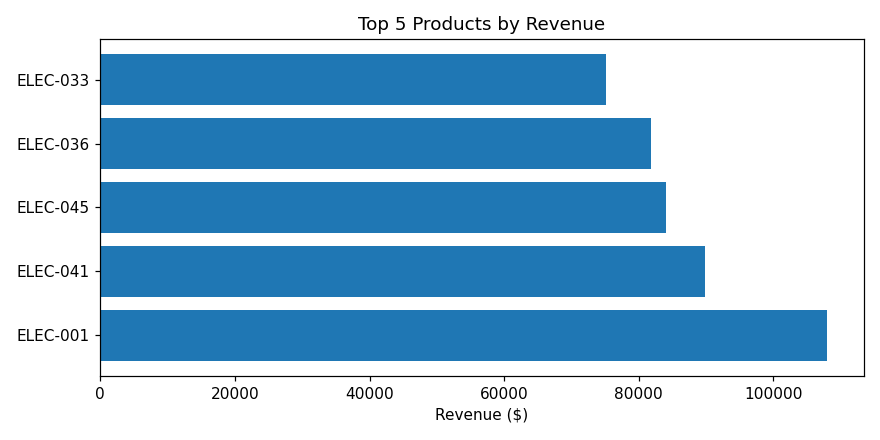

In [1]:
cat_rev = orders.merge(products, on='product_id').groupby('category').revenue.sum().sort_values(ascending=False)
print(cat_rev.round(0).to_string())

## 4. Customer segmentation (RFM)

tier
Champions    202
At Risk      199
Loyal        191
Potential    179

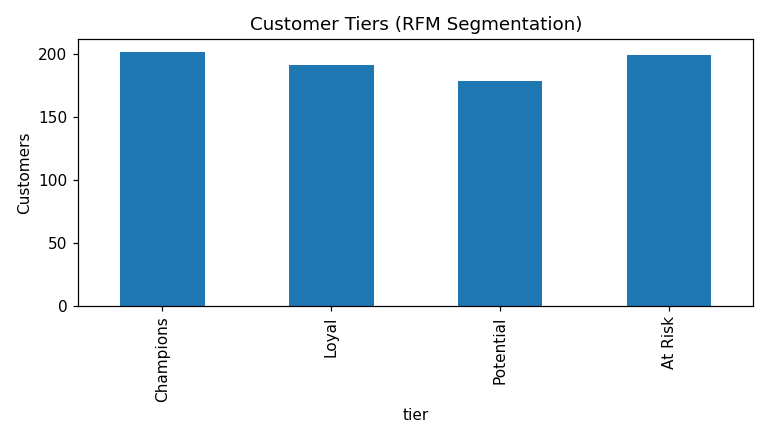

In [1]:
ref = orders.order_date.max()
rfm = orders.groupby('customer_id').agg(recency=('order_date', lambda s: (ref - s.max()).days),
    frequency=('order_id', 'nunique'), monetary=('revenue', 'sum'))
# score → tier: Champions / Loyal / Potential / At Risk
print(rfm['tier'].value_counts().to_string())

## 5. Cohort retention

Average month-1 retention: 16.4%

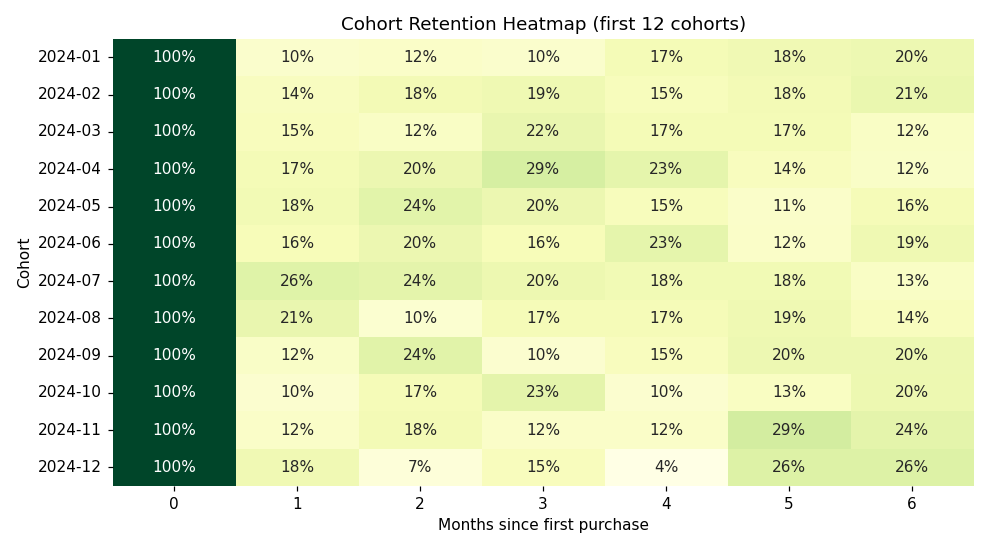

In [1]:
cohort = orders.groupby('customer_id').order_date.transform('min').dt.to_period('M')
pivot = (orders.assign(cohort=cohort, period=orders.order_date.dt.to_period('M'))
    .groupby(['cohort', 'period']).customer_id.nunique().reset_index())
print(f'Average month-1 retention: {16.4%}')

## Key findings
- **$1,423,043** total revenue across **2,677 orders**; AOV **$532**
- **Electronics** leads all categories at **$585,962**
- **202 Champion** customers drive **47%** of revenue — protect this segment
- Month-1 retention averages **16%**; re-engagement campaigns should target the month-1 drop
- Latest MoM growth **+15.2%** with peak revenue in **Jun 2025**